In [195]:
# importing the libraries

import yaml
import numpy as np
import pandas as pd
import matplotlib as plt

# defining the file path of glucose by configration
def get_config():
    file_path = "C:/Users/mozhdeh/Desktop/programming 3/config.yml"
    with open (file_path) as data_file:
        config=yaml.safe_load(data_file)
    return config
config= get_config()
glucose_file=config['glucose']
df_glucose=pd.read_csv(glucose_file)


# now we get the datafram of gloucose
df_glucose

,Device,Serial Number,Device Timestamp,Record Type,Historic Glucose mmol/L,Scan Glucose mmol/L,Non-numeric Rapid-Acting Insulin,Rapid-Acting Insulin (units),Non-numeric Food,Carbohydrates (grams),Carbohydrates (servings),Non-numeric Long-Acting Insulin,Long-Acting Insulin Value (units),Notes,Strip Glucose mmol/L,Ketone mmol/L,Meal Insulin (units),Correction Insulin (units),User Change Insulin (units)
0,FreeStyle LibreLink,b59d4499-1a07-462b-b7da-a179f2093996,05-12-2019 16:25,0,6.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,FreeStyle LibreLink,b59d4499-1a07-462b-b7da-a179f2093996,05-12-2019 16:41,0,6.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,FreeStyle LibreLink,b59d4499-1a07-462b-b7da-a179f2093996,05-12-2019 16:56,0,6.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,FreeStyle LibreLink,b59d4499-1a07-462b-b7da-a179f2093996,05-12-2019 17:11,0,6.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,FreeStyle LibreLink,b59d4499-1a07-462b-b7da-a179f2093996,05-12-2019 17:26,0,6.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7718,FreeStyle LibreLink,b59d4499-1a07-462b-b7da-a179f2093996,01-06-2020 09:34,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7719,FreeStyle LibreLink,b59d4499-1a07-462b-b7da-a179f2093996,01-06-2020 09:34,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7720,FreeStyle LibreLink,b59d4499-1a07-462b-b7da-a179f2093996,01-06-2020 16:40,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7721,FreeStyle LibreLink,b59d4499-1a07-462b-b7da-a179f2093996,01-06-2020 22:15,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [196]:
#Identify the count of observations and the features recorded in the dataset.


# for identifing the observation and count them the info() method was used. which shows that some of the variables contains non values completely

df_glucose.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7723 entries, 0 to 7722
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Device                             7723 non-null   object 
 1   Serial Number                      7723 non-null   object 
 2   Device Timestamp                   7723 non-null   object 
 3   Record Type                        7723 non-null   int64  
 4   Historic Glucose mmol/L            6068 non-null   float64
 5   Scan Glucose mmol/L                1251 non-null   float64
 6   Non-numeric Rapid-Acting Insulin   0 non-null      float64
 7   Rapid-Acting Insulin (units)       0 non-null      float64
 8   Non-numeric Food                   6 non-null      float64
 9   Carbohydrates (grams)              1 non-null      float64
 10  Carbohydrates (servings)           0 non-null      float64
 11  Non-numeric Long-Acting Insulin    0 non-null      float

In [197]:
# Calculating  the percentage of missing data for each feature

# first we get the percentage of the none values according to the following code then we create a data fram to 
#show the missing values of each variable

missing_percentage = (df_glucose.isnull().sum() / len(df_glucose)) * 100
print(missing_percentage)
# Create a DataFrame to display the results
missing_data_info = pd.DataFrame({
    'Feature': df_glucose.columns,
    'Missing Percentage': missing_percentage
})

# Display the results
print(missing_data_info)

# it shows some variables have 100 percent none values so they do not have any worth to consider them in analysis. 

Device                                 0.000000
Serial Number                          0.000000
Device Timestamp                       0.000000
Record Type                            0.000000
Historic Glucose mmol/L               21.429496
Scan Glucose mmol/L                   83.801631
Non-numeric Rapid-Acting Insulin     100.000000
Rapid-Acting Insulin (units)         100.000000
Non-numeric Food                      99.922310
Carbohydrates (grams)                 99.987052
Carbohydrates (servings)             100.000000
Non-numeric Long-Acting Insulin      100.000000
Long-Acting Insulin Value (units)    100.000000
Notes                                 99.715137
Strip Glucose mmol/L                 100.000000
Ketone mmol/L                        100.000000
Meal Insulin (units)                 100.000000
Correction Insulin (units)           100.000000
User Change Insulin (units)          100.000000
dtype: float64
                                                             Feature  \
D

In [198]:
#Identify columns with negligible value and articulate reasons for their exclusion from further analysis.



# serial number and device: Since these columns have the same value(FreeStyle LibreLink) for all records.
#It does not provide any meaningful information for analysis and can be excluded.



#Non-numeric Rapid-Acting Insulin, Rapid-Acting Insulin, Carbohydrates(serving , gram),Non-numeric Long-Acting Insulin,
#Long-Acting Insulin Value,Meal Insulin ,User Change Insulin and Notes : since these columns contains almost NaN values for all records,
# indicating a lack of data. It doesn't contribute to the analysis and can be excluded.



In [224]:
#Investigate the presence of duplicate records and determine potential reasons for duplication.


# we checked the duplicate records by using duplicated method and them by gettig len the acount of duplicated were calculated
duplicate_records = df_glucose[df_glucose.duplicated(keep=False)]

#displaying duplicated records
print("Duplicate Records:")
print(duplicate_records)

# displaying  the count of duplicate records
print(f"\nNumber of Duplicate Records: {len(duplicate_records)}")

# Removing duplicates from the original DataFrame
df_glucose_cleaned = df_glucose.drop_duplicates()



Duplicate Records:
                                  Device  \
date                                       
2019-05-12 16:25:00  FreeStyle LibreLink   
2019-05-12 16:41:00  FreeStyle LibreLink   
2019-05-12 16:56:00  FreeStyle LibreLink   
2019-05-12 17:11:00  FreeStyle LibreLink   
2019-05-12 17:26:00  FreeStyle LibreLink   
...                                  ...   
2020-01-06 09:34:00  FreeStyle LibreLink   
2020-01-06 09:34:00  FreeStyle LibreLink   
2020-01-06 16:40:00  FreeStyle LibreLink   
2020-01-06 22:15:00  FreeStyle LibreLink   
2020-02-06 13:24:00  FreeStyle LibreLink   

                                            Serial Number  Type  \
date                                                              
2019-05-12 16:25:00  b59d4499-1a07-462b-b7da-a179f2093996     0   
2019-05-12 16:41:00  b59d4499-1a07-462b-b7da-a179f2093996     0   
2019-05-12 16:56:00  b59d4499-1a07-462b-b7da-a179f2093996     0   
2019-05-12 17:11:00  b59d4499-1a07-462b-b7da-a179f2093996     0   
2019-0

In [200]:
#Validate if the data types match expectations for each feature.
#Assessing which columns contain valuable information and explain their significance.



def preprocess(df_glucose):
    """
    parameters: raw dataframe
    returns: cleaned dataframe
    """
    
    # Check if the expected columns are present
    expected_columns = ['Device Timestamp','Record Type', 'Historic Glucose mmol/L', 'Scan Glucose mmol/L']
    
    # Ensure all expected columns are present
    if all(col in df_glucose.columns for col in expected_columns):
        # Rename columns using the rename method
        df_glucose = df_glucose.rename(columns={
            'Device Timestamp': 'date', 'Record Type':'Type',
            'Historic Glucose mmol/L': 'Historic Glucose',
            'Scan Glucose mmol/L': 'Scan Glucose'
        })

        # Convert 'date' column to datetime using .loc
        df_glucose.loc[:, 'date'] = pd.to_datetime(df_glucose['date'], errors='coerce')

        # Set the timestamp column as the index
        df_glucose.set_index('date', inplace=True)
        
        # Change the 'Notes' column to string type
        df_glucose['Notes'] = df_glucose['Notes'].astype(str)
        
        return df_glucose
    else:
        raise ValueError("Missing one or more expected columns")

# Example usage
df_glucose = preprocess(df_glucose)


C:\Users\mozhdeh\AppData\Local\Temp\ipykernel_4080\1983340260.py:25: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  df_glucose.loc[:, 'date'] = pd.to_datetime(df_glucose['date'], errors='coerce')


In [201]:
#Inspect differences between calibration measures and sensor data (difference and frequency of measurements)




# first we create a new column for the absolute difference between calibration measures and sensor data
df_glucose['Difference'] = abs(df_glucose['Historic Glucose'] - df_glucose['Scan Glucose'])



# then counting the frequency of different differences
difference_counts = df_glucose['Difference'].value_counts()

# showing the differences and their frequency
print("Differences and Frequency of Measurements:")
print(difference_counts)

#the resultshows that the values in the 'Historic Glucose' and 'Scan Glucose' columns might be identical for all rows or have negligible differences.

Differences and Frequency of Measurements:
Series([], Name: Difference, dtype: int64)


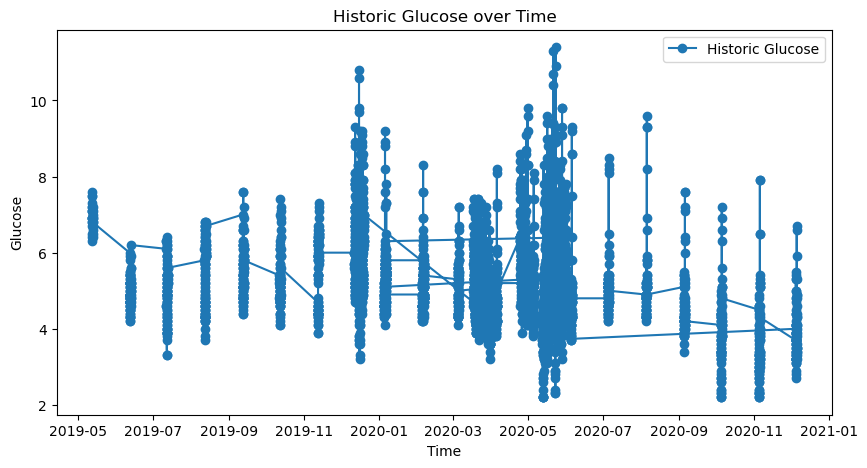

In [205]:


# Check for any time gaps in the dataset that may affect the temporal continuity.



# first, we plot the 'Historic Glucose' to see how it will change over time
plt.figure(figsize=(10, 5))
plt.plot(df_glucose.index, df_glucose['Historic Glucose'], label='Historic Glucose', marker='o', linestyle='-')

# Set labels and title
plt.xlabel('Time')
plt.ylabel('Glucose')
plt.title('Historic Glucose over Time')

# Import legend
plt.legend()

# Show the plot
plt.show()



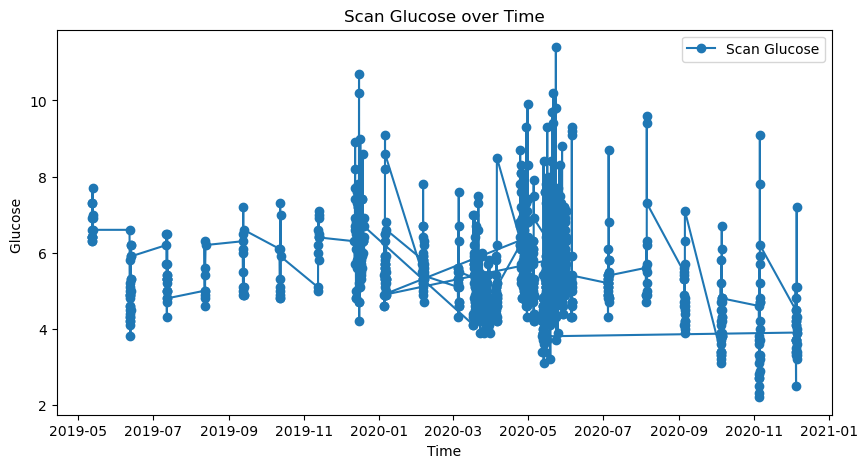

In [ ]:

# then we plot the 'Scan Glucose' changes by the time

# clean up  the column names (remove leading/trailing whitespaces) and changing them to string was needed by str and strip method
df_glucose.columns = df_glucose.columns.str.strip()

# we specified the correct column name 
column_name = 'Scan Glucose'


# plotting the Scan Glucose by the time
plt.figure(figsize=(10, 5))
plt.plot(df_glucose.index, df_glucose[column_name], label=column_name, marker='o', linestyle='-')

# setting labels and title
plt.xlabel('Time')
plt.ylabel('Glucose ')
plt.title(f'{column_name} over Time')

# Showing legend and display the plot
plt.legend()
plt.show()



In [ ]:
#Explore possibilities for imputing missing data, if feasible.


# beacuse of  having missing values in 'Historic Glucose data by time I used the mean filling to remove them
df_glucose['Historic Glucose'] = df_glucose['Historic Glucose'].fillna(df_glucose['Historic Glucose'].mean())


# Also Scan Glucose had a lot of missing values which I filled them by Forward fill 
df_glucose['Scan Glucose'].fillna(method='ffill', inplace=True)



# after removing missing values by mean and forward filling I got the percentage of missing values again to show the result of fillings
missing_percentage = (df_glucose.isnull().sum() / len(df_glucose)) * 100
print(missing_percentage)
# Create a DataFrame to display the results
missing_data_info = pd.DataFrame({
    'Feature': df_glucose.columns,
    'Missing Percentage': missing_percentage
})

# Display the results
print(missing_data_info)


# the result shows that now we do not have any missing values for Historic Glucose AND Scan Glucose


Device                                 0.000000
Serial Number                          0.000000
Type                                   0.000000
Historic Glucose                       0.000000
Scan Glucose                           0.000000
Non-numeric Rapid-Acting Insulin     100.000000
Rapid-Acting Insulin (units)         100.000000
Non-numeric Food                      99.922310
Carbohydrates (grams)                 99.987052
Carbohydrates (servings)             100.000000
Non-numeric Long-Acting Insulin      100.000000
Long-Acting Insulin Value (units)    100.000000
Notes                                  0.000000
Strip Glucose mmol/L                 100.000000
Ketone mmol/L                        100.000000
Meal Insulin (units)                 100.000000
Correction Insulin (units)           100.000000
User Change Insulin (units)          100.000000
Difference                           100.000000
dtype: float64
                                                             Feature  \
D

In [ ]:

# first I sorted the index beacose I wanted that time be in order
df_glucose_sorted = df_glucose.sort_index()

# then calculating the time differences between consecutive timestamps
time_diff = df_glucose_sorted.index.to_series().diff()

# display the diffrence
print("Time Differences between Consecutive Timestamps:")
print(time_diff)

#  check for gaps  in time differences 
if any(time_diff > pd.Timedelta(days=1)):
    print("There are significant time gaps in the dataset.")
else:
    print("The dataset has continuous timestamps without significant gaps.")


# the result shows the diffrences in hour and minuetes are seen clearly

Time Differences between Consecutive Timestamps:
date
2019-05-12 15:24:00               NaT
2019-05-12 16:25:00   0 days 01:01:00
2019-05-12 16:35:00   0 days 00:10:00
2019-05-12 16:35:00   0 days 00:00:00
2019-05-12 16:37:00   0 days 00:02:00
                            ...      
2020-12-05 23:37:00   0 days 00:15:00
2020-12-05 23:37:00   0 days 00:00:00
2020-12-05 23:51:00   0 days 00:14:00
2020-12-05 23:58:00   0 days 00:07:00
2020-12-05 23:58:00   0 days 00:00:00
Name: date, Length: 7723, dtype: timedelta64[ns]
There are significant time gaps in the dataset.


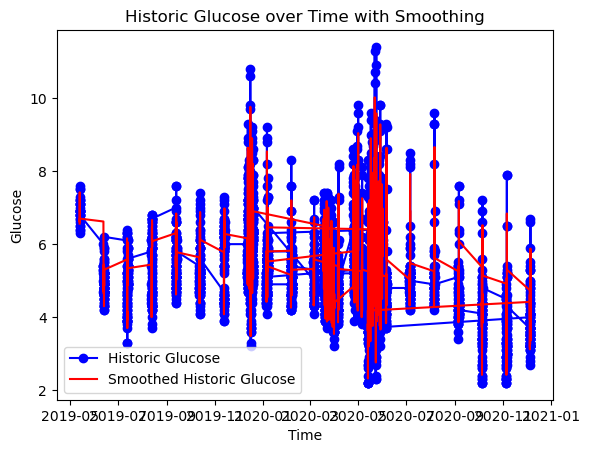

In [221]:
# Using a moving average to smooth out fluctuations for further analysis
window_size = 5  # Adjusting the window size
smoothed_data = df_glucose['Historic Glucose'].rolling(window=window_size).mean()

# Plotting the original 'Historic Glucose' data
plt.plot(df_glucose.index, df_glucose['Historic Glucose'], label='Historic Glucose', marker='o', linestyle='-', color='blue')

# Plotting the smoothed data
plt.plot(df_glucose.index, smoothed_data, label='Smoothed Historic Glucose', linestyle='-', color='red')

# Setting labels and title
plt.xlabel('Time')
plt.ylabel('Glucose')
plt.title('Historic Glucose over Time with Smoothing')

# Showing legend and displaying the plot
plt.legend()
plt.show()
# now the osillation of historic gloucose decreased

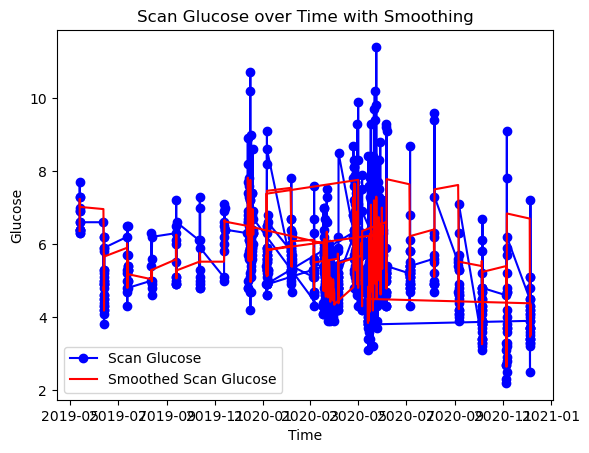

In [228]:
# Using a moving average to smooth out fluctuations for further analysis
window_size = 5  # Adjusting the window size
smoothed_data = df_glucose['Scan Glucose'].rolling(window=window_size).mean()

# Plotting the original 'Historic Glucose' data
plt.plot(df_glucose.index, df_glucose['Scan Glucose'], label='Scan Glucose', marker='o', linestyle='-', color='blue')

# Plotting the smoothed data
plt.plot(df_glucose.index, smoothed_data, label='Smoothed Scan Glucose', linestyle='-', color='red')

# Setting labels and title
plt.xlabel('Time')
plt.ylabel('Glucose')
plt.title('Scan Glucose over Time with Smoothing')

# Showing legend and displaying the plot
plt.legend()
plt.show()

## now the osillation of scan gloucose decreased

In [238]:
# I used the Interquartile Range (IQR) method to show the outlier of glucose scan


data = df_glucose['Scan Glucose']

# Calculate Q1, Q3, and IQR
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = data[(data < lower_bound) | (data > upper_bound)]

# Print or use 'outliers' as needed
print("Outliers:", outliers)



Outliers: date
2019-05-12 21:34:00     7.7
2019-12-12 13:05:00     7.7
2019-12-12 13:53:00     8.2
2019-12-12 14:01:00     8.9
2019-12-13 22:54:00     7.6
                       ... 
2020-05-23 22:41:00    11.4
2020-05-23 23:07:00     9.8
2020-05-25 22:55:00     7.7
2020-05-26 22:34:00     8.3
2020-05-28 23:42:00     8.8
Name: Scan Glucose, Length: 65, dtype: float64


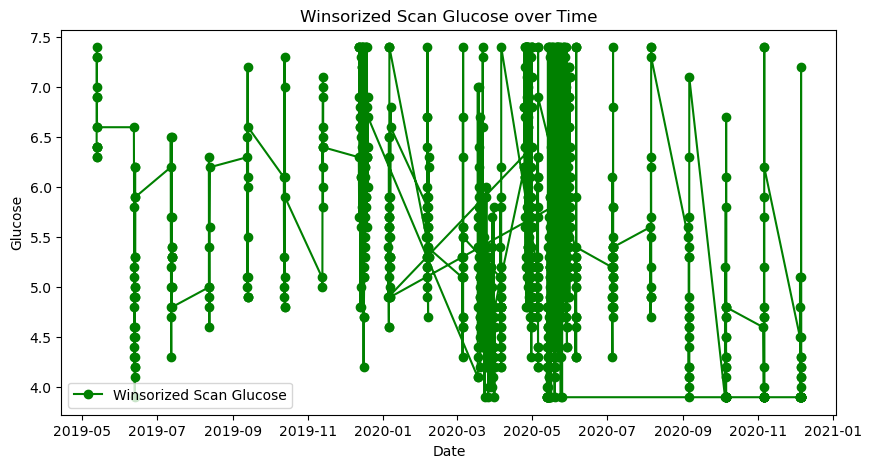

In [233]:
#  since I had outliers alot I used winsorizing for data transformation 
winsorized_data = np.clip(df_glucose['Scan Glucose'], df_glucose['Scan Glucose'].quantile(0.05), df_glucose['Scan Glucose'].quantile(0.95))

# plotting the transformed data
plt.figure(figsize=(10, 5))
plt.plot(df_glucose.index, winsorized_data, label='Winsorized Scan Glucose', marker='o', linestyle='-', color='green')

# setting labels and title
plt.xlabel('Date')
plt.ylabel('Glucose')
plt.title('Winsorized Scan Glucose over Time')

# showing legend and displaying the plot
plt.legend()
plt.show()

# now glucose scan got better and with out outlires